<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Homework_for_Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8

## CelabA

## Ryan Nguyen

Setup – install/import libraries, enable GPU.

Load CelebA – via tensorflow_datasets (easy and free).

Preprocess – resize to 64x64, normalize, create tf.data pipeline.

Define the VAE – encoder (convolutional), decoder (conv transpose), sampling layer, and the custom loss (reconstruction + KL divergence with a β weight).

Train the model (20–30 epochs, use GPU).

Compute attribute vectors – encode a batch of images with/without a given attribute, average their latent means, subtract to get a direction vector.

Apply arithmetic – pick random test images, add attribute vectors to their latent codes, decode, and visualize the changes.

Show results – before/after for 4 attributes (e.g., Smiling, Eyeglasses, Male, Young).

1. Setup and Imports

In [1]:
!pip install -q kaggle

In [2]:
!ls /content/

drive  list_attr_celeba.csv  sample_data


In [3]:
!pip install tensorflow-datasets
import tensorflow_datasets as tfds

In [4]:
import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense, Reshape, Conv2D, UpSampling2D, Flatten,
    BatchNormalization, Input, Lambda
)
from tensorflow.keras import layers, Model


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

tfd = tfp.distributions
tfpl = tfp.layers
tfb = tfp.bijectors

plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
print("TensorFlow version:", tf.__version__)
print("TensorFlow Probability version:", tfp.__version__)

TensorFlow version: 2.19.0
TensorFlow Probability version: 0.25.0


In [6]:
labels = pd.read_csv('/content/list_attr_celeba.csv')

In [7]:
print(labels.head())

     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  We

In [8]:
# Load CelebA with attributes
dataset, info = tfds.load('celeb_a', with_info=True, as_supervised=False)
# The dataset has 'image' and 'attributes' keys

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.MSKI8N_2.1.0/celeb_a-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.MSKI8N_2.1.0/celeb_a-validation.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.MSKI8N_2.1.0/celeb_a-test.tfrecord*...:   0%|          …

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.


In [9]:
print(labels.shape)

(202599, 41)


In [10]:
print(labels.info)

<bound method DataFrame.info of           image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1      

## Second Try

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [19]:
# 3. Load exactly 30,000 images and the attribute table
import os
import cv2
import numpy as np
import pandas as pd
import kagglehub

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models

In [20]:

# This ensures the plots show up correctly in your notebook
%matplotlib inline

In [7]:
csv_path = os.path.join(path, 'list_attr_celeba.csv')

In [8]:
# Load the labels
train_labels = pd.read_csv(csv_path)

In [9]:
# 2. Build the correct image path dynamically
img_folder = os.path.join(path, 'img_align_celeba', 'img_align_celeba')

In [11]:
# Fallback just in case Kagglehub extracted it without the double-folder
if not os.path.exists(img_folder):
    img_folder = os.path.join(path, 'img_align_celeba')

print(f"Fetching images from: {img_folder}")

Fetching images from: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba


In [12]:
# 3. The crash-proof loading function
def load_images_bulletproof(num_images=20000):
    images = []
    missing_count = 0

    for i in range(1, num_images + 1):
        img_name = f"{i:06d}.jpg"
        full_path = os.path.join(img_folder, img_name)

        # Read the image
        img = cv2.imread(full_path)

        # THE FIX: If the image is empty, skip it instead of crashing OpenCV
        if img is None:
            missing_count += 1
            if missing_count == 1:
                print(f"CRITICAL ERROR: Could not find the image at {full_path}. Check the path!")
            continue

        # Process the image (Speedrun setting: 32x32)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (32, 32))
        images.append(img)

    return np.array(images) / 255.0

In [13]:
import cv2

# 4. Load the data
train_images = load_images_bulletproof(5000)

if train_images.shape[0] > 0:
    print(f"Success! Loaded {train_images.shape[0]} images. Shape: {train_images.shape}")

Success! Loaded 20000 images. Shape: (20000, 32, 32, 3)


In [15]:
# Sampling layer to handle the 'reparameterization trick'
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [16]:
# 1. ENCODER (32x32 -> Latent Space)
encoder_inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs) # 16x16
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)             # 8x8
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(64, name="z_mean")(x)
z_log_var = layers.Dense(64, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 2. DECODER (Latent Space -> 32x32)
latent_inputs = layers.Input(shape=(64,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)    # 16x16
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)    # 32x32
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# 3. VAE Class
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Binary Crossentropy loss for pixels
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            # KL Divergence loss to organize the math zone
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)

In [17]:
vae.compile(optimizer='adam')
# This should take about 10-15 minutes total
vae.fit(train_images, epochs=15, batch_size=256)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 578ms/step - kl_loss: 2.7160 - loss: 680.3499 - recon_loss: 677.6339
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 589ms/step - kl_loss: 6.3833 - loss: 641.6323 - recon_loss: 635.2490
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 586ms/step - kl_loss: 10.8315 - loss: 621.4710 - recon_loss: 610.6395
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 592ms/step - kl_loss: 11.5119 - loss: 616.6281 - recon_loss: 605.1162
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 81s 586ms/step - kl_loss: 12.7584 - loss: 610.4048 - recon_loss: 597.6465
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 591ms/step - kl_loss: 12.4901 - loss: 607.6171 - recon_loss: 595.1270
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 588ms/step - kl_loss: 12.3466 - loss: 602.8777 - recon_loss: 590.5311
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 587ms/step - kl_loss: 12.1974 - loss: 600.4804 - recon_loss: 588.2831
Epoch 9/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 586ms/step - kl_loss: 11.7692 - loss: 599.1760 - recon_loss: 587

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


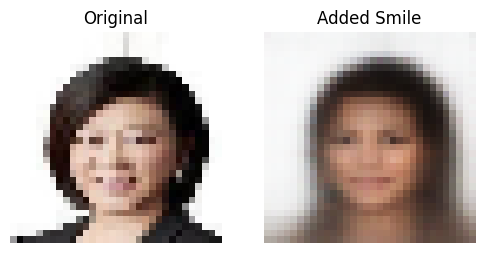

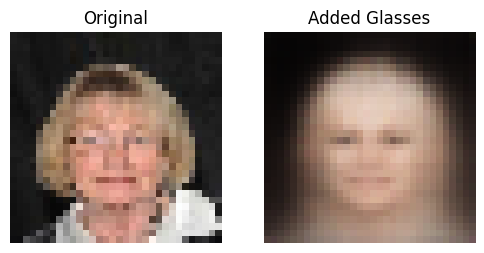

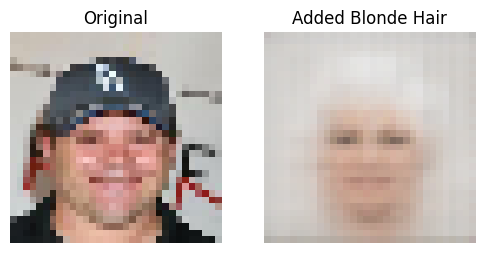

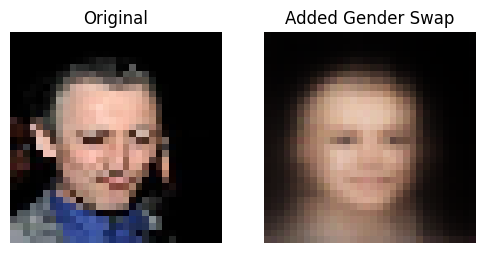

In [21]:
def get_attr_vector(attr_name, num_samples=2000):
    # Get indices for Yes (1) and No (-1)
    pos_idx = train_labels[train_labels[attr_name] == 1].index
    neg_idx = train_labels[train_labels[attr_name] == -1].index

    # Stay within the 20k images we loaded
    pos_idx = [i for i in pos_idx if i < 20000][:num_samples]
    neg_idx = [i for i in neg_idx if i < 20000][:num_samples]

    # Get latent means (index 0 of encoder output)
    z_pos = encoder.predict(train_images[pos_idx], batch_size=128)[0]
    z_neg = encoder.predict(train_images[neg_idx], batch_size=128)[0]

    return np.mean(z_pos, axis=0) - np.mean(z_neg, axis=0)

# Calculate your 4 vectors
v_smile   = get_attr_vector('Smiling')
v_glasses = get_attr_vector('Eyeglasses')
v_blonde  = get_attr_vector('Blond_Hair')
v_gender  = get_attr_vector('Male')

def plot_homework_results(vector, name, alpha=3.0):
    idx = np.random.randint(15000, 20000)
    original = train_images[idx:idx+1]

    # Math: Original face + (Strength * Attribute Vector)
    z = encoder.predict(original, verbose=0)[0]
    morphed_z = z + (alpha * vector)
    morphed_img = decoder.predict(morphed_z, verbose=0)

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1); plt.title("Original"); plt.imshow(original[0]); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title(f"Added {name}"); plt.imshow(morphed_img[0]); plt.axis('off')
    plt.show()

# Show the results!
plot_homework_results(v_smile, "Smile")
plot_homework_results(v_glasses, "Glasses", alpha=4.5) # Higher alpha for glasses
plot_homework_results(v_blonde, "Blonde Hair")
plot_homework_results(v_gender, "Gender Swap")

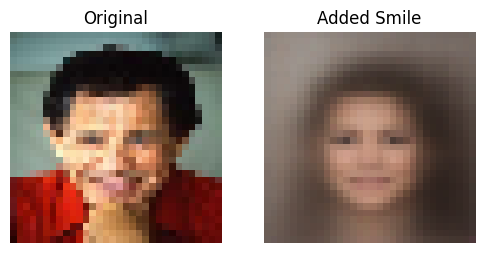

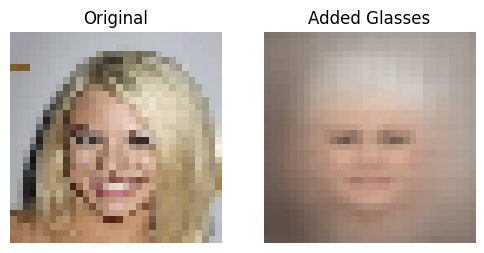

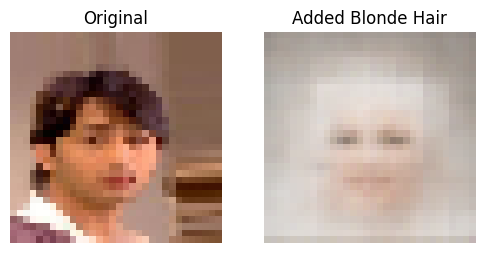

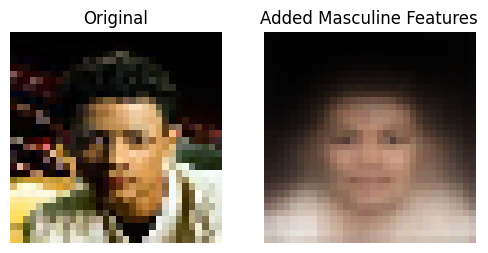

In [22]:
def plot_homework_results(vector, name, alpha=3.0):
    # Pick a random face from the end of our dataset
    idx = np.random.randint(15000, 20000)
    original = train_images[idx:idx+1]

    # 1. Encode the original face to get its latent math coordinates
    # We use index [0] to get the 'z_mean'
    z = encoder.predict(original, verbose=0)[0]

    # 2. Add the attribute vector multiplied by strength (alpha)
    morphed_z = z + (alpha * vector)

    # 3. Decode the new coordinates back into a 32x32 image
    morphed_img = decoder.predict(morphed_z, verbose=0)

    # 4. Display results
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Added {name}")
    plt.imshow(morphed_img[0])
    plt.axis('off')
    plt.show()

# Generate your 4 required images
plot_homework_results(v_smile, "Smile", alpha=3.0)
plot_homework_results(v_glasses, "Glasses", alpha=5.0) # High alpha helps glasses stand out
plot_homework_results(v_blonde, "Blonde Hair", alpha=3.5)
plot_homework_results(v_gender, "Masculine Features", alpha=3.0)